Step 1: Load Dataset & Setup Libraries

import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Load Datasets

In [2]:
sales_data = pd.read_csv(
    "../outputs/feature_engineered_sales_data.csv"
)

Convert Order Date

In [6]:
sales_data["Order_Date"] = pd.to_datetime(
    sales_data["Order_Date"],
    errors="coerce"
)

Create Year-Month Column

In [ ]:
sales_data["Year_Month"] = (
    sales_data["Order_Date"].dt.strftime("%Y-%m")
)

Visualization Style

In [7]:
plt.style.use("default")

Step 2: Sales by Region — Bar Chart

Calculate Sales by Region

In [8]:
sales_by_region = (
    sales_data.groupby("Region")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

Region
West       1.036566e+08
North      1.027134e+08
South      9.639006e+07
East       5.023940e+07
Central    2.880588e+07
Name: Net_Sales, dtype: float64

In [13]:
sales_by_region = (
    sales_data.groupby("Region")["Net_Sales"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
)
sales_by_region

Region
West       1.036566e+08
North      1.027134e+08
South      9.639006e+07
East       5.023940e+07
Central    2.880588e+07
Name: Net_Sales, dtype: float64

In [14]:
sales_by_region_crore = sales_by_region / 1e7

Create Bar Chart

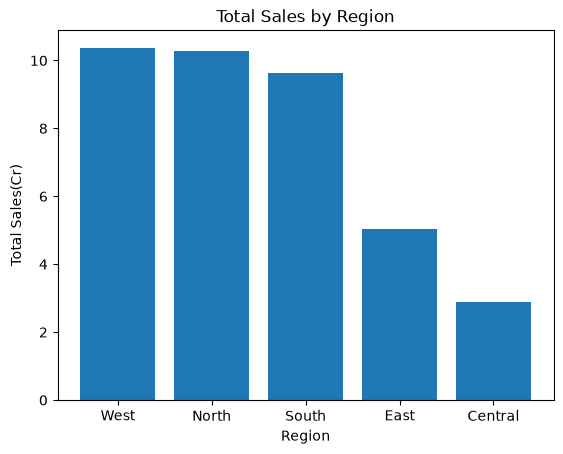

In [17]:
plt.bar(
    sales_by_region_crore.index,
    sales_by_region_crore.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales(Cr)")

plt.show()

Step 4: Monthly Sales Trend — Line Chart


In [22]:
sales_data["Year_Month"] = (
    sales_data["Order_Date"].dt.strftime("%y-%m")
)

Step 4.1: Calculate Monthly Sales

In [29]:
# 2025
monthly_sales = (
    sales_data[sales_data["Order_Date"].dt.year == 2025]
    .groupby("Year_Month")["Net_Sales"]
    .sum()
    .sort_index()
)
monthly_sales

Year_Month
25-01     9016180.85
25-02     8475266.10
25-03    10051322.55
25-04     9822315.30
25-05    10673457.45
25-06    10337091.85
25-07    10149530.90
25-08    10090166.15
25-09    10283140.80
25-10    11776907.45
25-11    11295681.55
25-12    10581553.55
Name: Net_Sales, dtype: float64

Create Line Chart

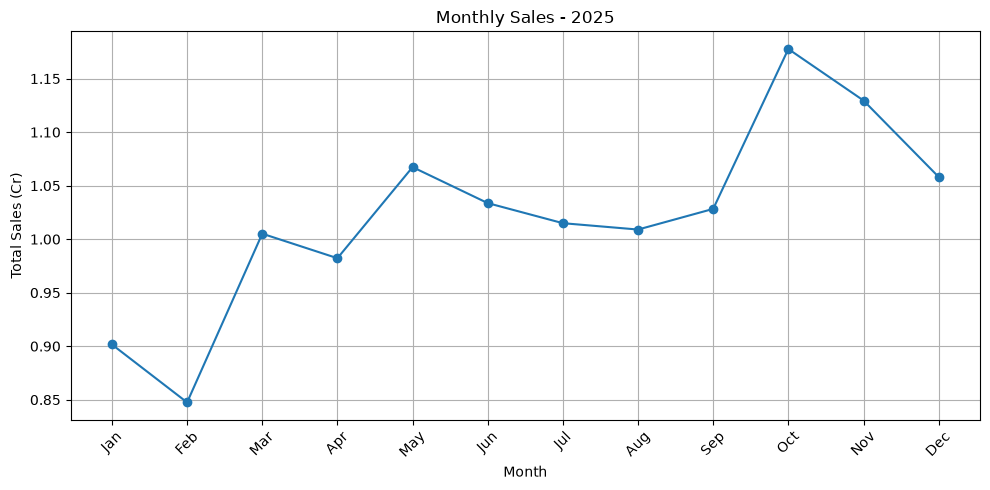

In [43]:
monthly_sales_crore = monthly_sales / 10_000_000

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_crore.index,
    monthly_sales_crore.values,
    marker="o"
)

plt.title("Monthly Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Total Sales (Cr)")

plt.xticks(
    ticks=monthly_sales_crore.index,
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ],
    rotation=45
)

plt.grid(True)
plt.tight_layout()
plt.show()

Step 5: Top 10 Products by Sales

In [44]:
top_10_products = (
    sales_data.groupby("Product_Name")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_10_products_crore = top_10_products / 10_000_000

Horizontal Bar Chart

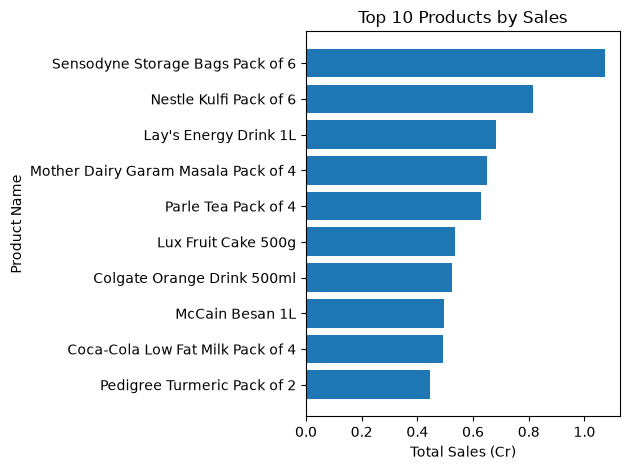

In [45]:
plt.Figure(figsize=(10,6))

plt.barh(
    top_10_products_crore.index[::-1],
    top_10_products_crore.values[::-1]
    
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales (Cr)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [46]:
top_10_products_crore.round(2)

Product_Name
Sensodyne Storage Bags Pack of 6       1.07
Nestle Kulfi Pack of 6                 0.82
Lay's Energy Drink 1L                  0.68
Mother Dairy Garam Masala Pack of 4    0.65
Parle Tea Pack of 4                    0.63
Lux Fruit Cake 500g                    0.54
Colgate Orange Drink 500ml             0.52
McCain Besan 1L                        0.50
Coca-Cola Low Fat Milk Pack of 4       0.49
Pedigree Turmeric Pack of 2            0.44
Name: Net_Sales, dtype: float64

Step 6: Profit by Category

Category-wise Profit

In [ ]:
profit_by_category = (
    sales_data.groupby("Category_Details")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
profit_by_category_crore = (
    profit_by_category / 10_000_000
).round(2)


Category_Details
Beverages              7670420.45
Staples                7592648.80
Dairy & Breakfast      6484048.20
Snacks                 6185506.25
Beauty & Hygiene       5408751.70
Packaged Food          4837292.70
Personal Care          4759510.20
Frozen Food            4171237.65
Fruits & Vegetables    4113646.40
Bakery                 3891261.50
Home Care              3710206.40
Household Items        2340653.60
Baby Care              1944831.70
Pet Care                822590.50
Name: Profit, dtype: float64

Bar Chart

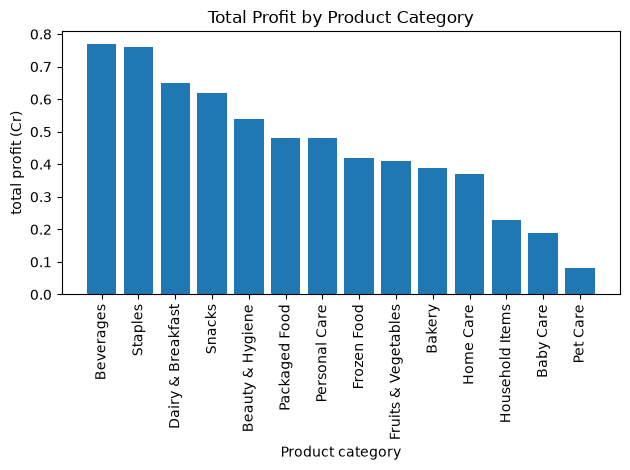

In [55]:
plt.bar(
    profit_by_category_crore.index,
    profit_by_category_crore.values
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product category")
plt.ylabel("total profit (Cr)")

plt.xticks(rotation =90)
plt.tight_layout()
plt.show()

In [57]:
profit_by_category

Category_Details
Beverages              7670420.45
Staples                7592648.80
Dairy & Breakfast      6484048.20
Snacks                 6185506.25
Beauty & Hygiene       5408751.70
Packaged Food          4837292.70
Personal Care          4759510.20
Frozen Food            4171237.65
Fruits & Vegetables    4113646.40
Bakery                 3891261.50
Home Care              3710206.40
Household Items        2340653.60
Baby Care              1944831.70
Pet Care                822590.50
Name: Profit, dtype: float64

Step 7: Payment Method Analysis

Payment Method-wise Sales

In [60]:
sales_by_payment = (
    sales_data.groupby("Payment_Method")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)


In [62]:
sales_by_payment_crore = (
    sales_by_payment / 10_000_000
).round(2)
sales_by_payment_crore

Payment_Method
UPI            21.45
Credit Card     5.37
Debit Card      3.75
Wallet          3.01
Cash            2.66
Net Banking     1.94
Name: Net_Sales, dtype: float64

Plot at Bar Chart

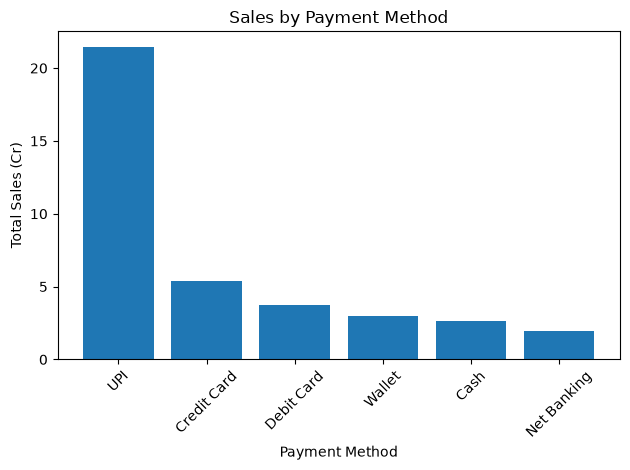

In [63]:

plt.bar(
    sales_by_payment_crore.index,
    sales_by_payment_crore.values
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales (Cr)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
sales_by_payment_crore

Payment_Method
UPI            21.45
Credit Card     5.37
Debit Card      3.75
Wallet          3.01
Cash            2.66
Net Banking     1.94
Name: Net_Sales, dtype: float64

Step 8: Order Status Analysis

Status-wise Sales

In [65]:
sales_by_status = (
    sales_data.groupby("Order_Status")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_status_crore = (
    sales_by_status / 10_000_000
).round(2)

sales_by_status_crore

Order_Status
Delivered    34.72
Cancelled     1.73
Pending       0.67
Returned      0.59
Failed        0.46
Name: Net_Sales, dtype: float64

Create Bar Chart

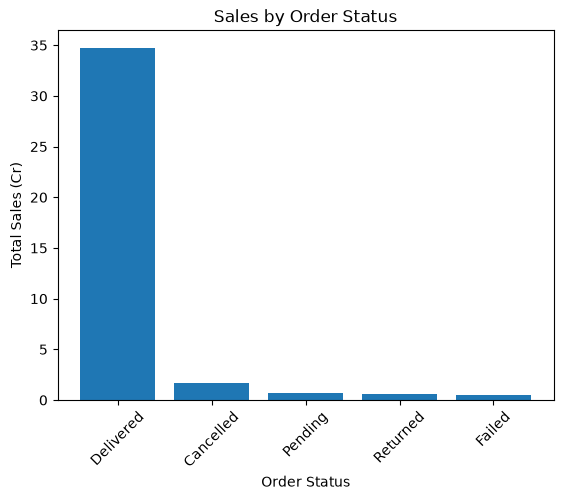

In [67]:
plt.bar(
    sales_by_status_crore.index,
    sales_by_status_crore.values
)
plt.title("Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales (Cr)")

plt.xticks(rotation=45)
plt.show()

In [68]:
sales_by_status_crore

Order_Status
Delivered    34.72
Cancelled     1.73
Pending       0.67
Returned      0.59
Failed        0.46
Name: Net_Sales, dtype: float64

Step 9: Customer Segment Analysis

Customer Segment Count

In [69]:
customers_segment_counts = (
    sales_data.groupby("Customer_ID")["Customer_Segment"]
    .first()
    .value_counts()
)
customers_segment_counts

Customer_Segment
Loyal High-Value customer    6027
Regular Customer             2597
Low-value Customer           1267
Name: count, dtype: int64

Bar Chart

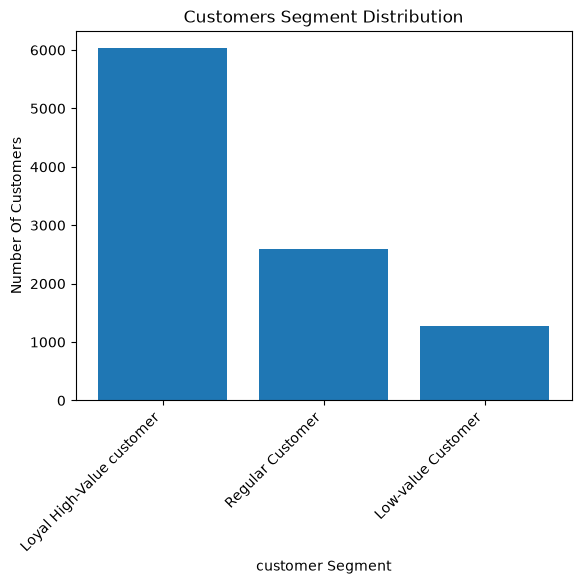

In [ ]:
plt.bar(
    customers_segment_counts.index,
    customers_segment_counts.values
)
plt.title("Customers Segment Distribution")
plt.xlabel("customer Segment")
plt.ylabel("Number Of Customers")

plt.xticks(rotation=45)
plt.show()

In [78]:
customers_segment_counts

Customer_Segment
Loyal High-Value customer    6027
Regular Customer             2597
Low-value Customer           1267
Name: count, dtype: int64

Step 10: Discount Analysis

Discount-wise Sales

In [79]:
sales_by_discount = (
    sales_data.groupby("Discount_Category")["Net_Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_discount_crore = (
    sales_by_discount / 10_000_000
).round(2)

sales_by_discount_crore

Discount_Category
Low Discount       17.54
No Discount        14.50
Medium Discount     5.45
High Discount       0.70
Name: Net_Sales, dtype: float64

Bar chart

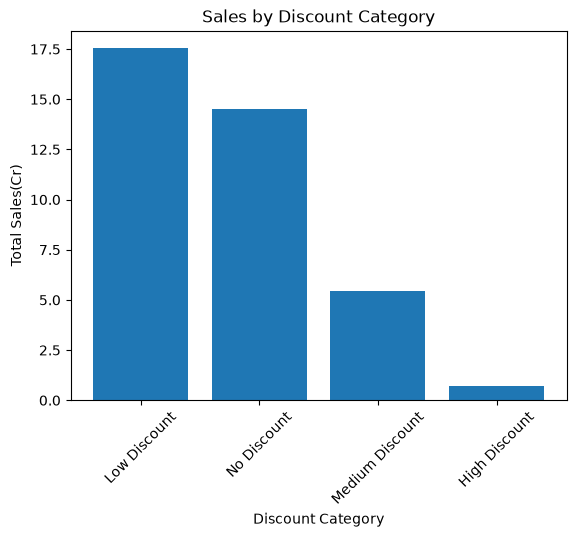

In [85]:
plt.bar(
    sales_by_discount_crore.index,
    sales_by_discount_crore.values
)
plt.title("Sales by Discount Category")
plt.xlabel("Discount Category")
plt.ylabel("Total Sales(Cr)")

plt.xticks(rotation=45)
plt.show()

Step 11: Save Charts

Create Charts Folder

In [86]:
import os

os.makedirs("..//outputs/charts",exist_ok=True)

Save All Charts

In [ ]:

# Save Category Sales Chart
plt.savefig(
    "../outputs/charts/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Monthly Sales Trend
plt.savefig(
    "../outputs/charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Top 10 Products
plt.savefig(
    "../outputs/charts/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Profit by Category
plt.savefig(
    "../outputs/charts/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Payment Method Analysis
plt.savefig(
    "../outputs/charts/sales_by_payment.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Order Status Analysis
plt.savefig(
    "../outputs/charts/sales_by_status.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Customer Segment Analysis
plt.savefig(
    "../outputs/charts/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

# Save Discount Analysis
plt.savefig(
    "../outputs/charts/sales_by_discount.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>